> DSC530 Data Exploration and Analysis
>
> Final Project Assignment
>
> Peter Lozano

*SOURCE
[Kaggle](https://www.kaggle.com/code/farzadnekouei/employee-turnover-prediction-xgboost-vs-catboost)


<img src="https://github.com/FarzadNekouee/XGBoost-CatBoost-Employee-Resignation/blob/master/image.jpg?raw=true" width="1800">

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:120%; text-align:left; color: black">

<h3 align="left"><font color=#009c05>Problem:</font></h3>

I work in HR analytics, and one of the key challenges we face is employee turnover. I felt as though that this project was interesting, relevant, and significant enough for not just the company I work for, but to all companies trying to retain talent.

It is costly in terms of both lost productivity and the expenses associated with recruiting, hiring, and training new employees. Understanding and predicting which employees are at risk of leaving can help an organization to take proactive steps to retain valuable employees and maintain organizational stability. 

In this project, I will use a dataset containing information about employees and whether or not they left the company. Our task is to build a model that can predict the probability that a given employee will leave the company. I will approach this binary classification problem using regression algorithms for reasons such as probabilistic interpretation, threshold calibration, and better performance on imbalanced data.

<a id="contents_tabel"></a>    
<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left">

<h3 align="left"><font color=#009c05>Table of Contents:</font></h3>
    
* [Step 1 | Import Libraries](#import)
* [Step 2 | Read Dataset](#read)
* [Step 3 | Dataset Overview](#overview)
    - [Step 3.1 | Dataset Basic Information](#basic)
    - [Step 3.2 | Summary Statistics for Numerical Variables](#num_statistics)
    - [Step 3.3 | Summary Statistics for Categorical Variables](#cat_statistics)
* [Step 4 | EDA](#eda)
    - [Step 4.1 | Numerical Features vs Target](#num_target)
    - [Step 4.2 | Distributions](#distro)
    - [Step 4.3 | Scaling and Normalization](#scale_norm)
    - [Step 4.4 | Correlation & Significance](#corr_sig)
    - [Step 4.5 | Numerical Features vs Employees that Left](#num_left)
* [Step 5 | Data Preprocessing](#preprocessing)
    - [Step 5.1 | Check Missing Values](#missing)
    - [Step 5.2 | Train-Test Split](#train_split)
    - [Step 5.3 | Classification Report](#classification)
    - [Step 5.4 | ROC Curve and AUC](#roc)
    - [Step 5.5 | Confusion Matrix](#confusion_matrix)
    - [Step 5.6 | Logistic Regression Conclusion](#logistic_conclusion)
* [Step 6 | Build XGBoost ~~Regressor~~ Classifier](#xgb)
    - [Step 6.1 | Tune XGBoost Classifier](#tune_xgb)
    - [Step 6.2 | Split the Dataset](#split_db)
    - [Step 6.3 | XGBoost Classification Report](#xgb_class_report)
    - [Step 6.4 | Classification Report With Noise](#xgb_w_noise)
    - [Step 6.5 | ROC AUC With Noise Comparison](#roc_noise_comp)
    - [Step 6.6 | PR Curve With Noise Comparison](#pr_noise_comp)
* [Step 7 | Conclusion](#conclusion)

<h2 align="left"><font color=#009c05>Let's get started:</font></h2>

<a id="import"></a>
# <p style="background-color: #009c05; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 1 | Import Libraries</p>

⬆️ [Tabel of Contents](#contents_tabel)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np                                     # Step 3.x, 4.x, 6.x, 7.x
import pandas as pd                                    # Step 4.x, 5.x, 6.x, 7.x
import matplotlib.pyplot as plt                        # Step 4.x, 5.x, 6.x, 7.x
import seaborn as sns                                  # Step 1
import xgboost as xgb                                  # Step 6.1
from sklearn.model_selection import (train_test_split, # Step 5.2
                                     GridSearchCV,     # Step 6.2
                                     StratifiedKFold   # Step 6.1
)
import pingouin as pg                                  # Step 4.4
import scipy.stats as stats                            # Step 4.3, 4.5

from sklearn.linear_model import LogisticRegression    # Step 5.2

from sklearn.metrics import (
    precision_recall_fscore_support,                   # Step 6.4, 7.1
    accuracy_score,                                    # Step 6.4, 7.1
    roc_auc_score,                                     # Step 5.2, 6.x, 7.1
    precision_recall_curve,                            # Step 6.4, 7.1
    average_precision_score,                           # Step 6.4, 7.1
    classification_report,                             # Step 5.3, 6.x, 7.1
    confusion_matrix,                                  # Step 5.5
    ConfusionMatrixDisplay                             # Step 5.5
)
from ml_utils.classification import plot_roc           # Step 5.4, 6.4, 7.2

In [2]:
# Configure Seaborn plot styles: Set background color and use dark grid
sns.set_theme(rc={'axes.facecolor': '#f1faeb'}, style='darkgrid')

<a id="read"></a>
# <p style="background-color:#009c05 ; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 2 | Read Dataset</p>

⬆️ [Tabel of Contents](#contents_tabel)

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: #000000d7">

First I will explore the data to see how it is structured (*wide, long*) and see what fields are available for analysis

In [3]:
# Load dataset
df = pd.read_csv('HR.csv')
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


<div style="border-radius:10px; padding: 15px; background-color:  #f0ffe3; font-size:120%; text-align:left; color: #000000d7">

## <h3 align="left"><font color=#009c05>Dataset Description:</font></h3>

| __Variable__ | __Description__ |
|     :---      |       :---      |      
| __satisfaction_level__ | The level of satisfaction of the employee |
| __last_evaluation__ | The score of the last evaluation of the employee |
| __number_project__ | The number of projects the employee has worked on |
| __average_montly_hours__ | The average monthly hours worked by the employee |
| __time_spend_company__ | The number of years the employee has spent at the company |                     
| __Work_accident__ | Whether the employee had a work accident (1 = yes, 0 = no) |
| __left__ | Whether the employee has left the company (1 = yes, 0 = no) |  
| __promotion_last_5years__ | Whether the employee had a promotion in the last 5 years (1 = yes, 0 = no) |                      
| __sales__ | The department the employee works in |
| __salary__ | The salary level of the employee (low, medium, high) |


<a id="overview"></a>
# <p style="background-color:#009c05; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 3 | Dataset Overview</p>

⬆️ [Tabel of Contents](#contents_tabel)

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">
    
Next, I'll delve into a detailed exploration of the dataset:

<a id="basic"></a>
## <b><span style='color:#8fc265'>Step 3.1 |</span><span style='color:#009c05'> Dataset Basic Information</span></b>

In [4]:
# Display a concise summary of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


<h2 align="left"><font color='#009c05'>Inference</font></h2>

<div style="border-radius:10px; padding: 15px; background-color:  #f0ffe3; font-size:120%; text-align:left; color: black">

* __Number of Entries__: The dataset consists of __14,999 entries__, ranging from index 0 to 14,998.
    
    
* __Columns__: There are __10 columns__ in the dataset corresponding to various attributes of the employees.
    
    
* __Data Types__:
    - Two of the columns are of the __float64__ data type.
    - Six of the columns are of the __int64__ data type.
    - Two of the columns are of the __object__ data type.
    
    
* __Missing Values__: There don't appear to be any missing values in the dataset as each column has 14,999 non-null entries.

    *Missing values would determine if we need to simulate data to fill in the gaps or not.*


<h2 align="left"><font color='#009c05'>Note</font></h2>

<div style="border-radius:10px; padding: 15px; background-color:  #f0ffe3; font-size:120%; text-align:left; color: black">

Based on the data types and the feature explanations provided earlier, I identified that __5 columns__ (`Work_accident`, `left`, `promotion_last_5years`, `sales`, `salary`) are __categorical__. These features must have string (__object__) data type to ensure proper analysis and interpretation in subsequent steps:

In [5]:
# Define the continuous features
continuous_features = ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company']

# Identify the features to be converted to object data type
features_to_convert = [feature for feature in df.columns if feature not in continuous_features]

# Convert the identified features to object data type
df[features_to_convert] = df[features_to_convert].astype('object')

df.dtypes

satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident             object
left                      object
promotion_last_5years     object
sales                     object
salary                    object
dtype: object

In [6]:
# Describe and Summarize the object data type columns in Table format
df.describe(include=object).T

,count,unique,top,freq
Work_accident,14999,2,0,12830
left,14999,2,0,11428
promotion_last_5years,14999,2,0,14680
sales,14999,10,sales,4140
salary,14999,3,low,7316


<a id="num_statistics"></a>
## <b><span style='color:#8fc265'>Step 3.2 |</span><span style='color:#009c05'> Summary Statistics for Numerical Variables</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">

Let's delve into the summary statistics for our __numerical__ attributes:

In [7]:
# Get the summary statistics for numerical variables
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
satisfaction_level,14999.0,NaN,NaN,NaN,0.612834,0.248631,0.09,0.44,0.64,0.82,1.0
last_evaluation,14999.0,NaN,NaN,NaN,0.716102,0.171169,0.36,0.56,0.72,0.87,1.0
number_project,14999.0,NaN,NaN,NaN,3.803054,1.232592,2.0,3.0,4.0,5.0,7.0
average_montly_hours,14999.0,NaN,NaN,NaN,201.050337,49.943099,96.0,156.0,200.0,245.0,310.0
time_spend_company,14999.0,NaN,NaN,NaN,3.498233,1.460136,2.0,3.0,3.0,4.0,10.0
Work_accident,14999.0,2.0,0.0,12830.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
left,14999.0,2.0,0.0,11428.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
promotion_last_5years,14999.0,2.0,0.0,14680.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sales,14999,10,sales,4140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary,14999,3,low,7316,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<h2 align="left"><font color='#009c05'>Inference for Numerical Variables</font></h2>

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">

* __`satisfaction_level`__: Varies from 0.09 to 1.00 with a mean satisfaction level of approximately 0.61.
    
    
* __`last_evaluation`__: Scores range from 0.36 to 1.00 with a mean score of approximately 0.72.
    
    
* __`number_project`__: Varies from 2 to 7 with an average number of projects being approximately 3.80.
    
    
* __`average_montly_hours`__: Worked by employees ranges from 96 to 310 hours with a mean of approximately 201 hours.
    
    
* __`time_spend_company`__: Ranges from 2 to 10 years with a mean of approximately 3.5 years.

<a id="cat_statistics"></a>
## <b><span style='color:#8fc265'>Step 3.3 |</span><span style='color:#009c05'> Summary Statistics for Categorical  Variables</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">

Afterward, let's look at the summary statistics of the categorical features:

In [8]:
# Get the summary statistics for categorical variables
df.describe(include='object')

,Work_accident,left,promotion_last_5years,sales,salary
count,14999,14999,14999,14999,14999
unique,2,2,2,10,3
top,0,0,0,sales,low
freq,12830,11428,14680,4140,7316


<h3 align="left"><font color=#009c05>Inference for Categorical Variables</font></h3>

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">

* __`Work_accident`__: [**Binary**] Two unique values, __0__ and __1__, with the majority of employees (12,830 out of 14,999) not having had a work accident.


* __`left`__: [**Binary**] Two unique values, 0 and 1. The majority of employees (11,428 out of 14,999) have not left the company, indicating that __the dataset is imbalanced__ towards employees who have not left.

* __`promotion_last_5years`__: [**Binary**] Two unique values, __0__ and __1__, with the majority of employees (14,680 out of 14,999) not having had a promotion in the last 5 years.

* __`sales`__: [**Nominal**] Ten unique values, representing the different departments. The '__sales__' department is the most common department in the dataset.

* __`salary`__: [**Ordinal**] Three unique values, '__low__', '__medium__', and '__high__', with '__low__' being the most common salary level in the dataset.



<h3 align="left"><font color=#009c05>Calculate Summary Statistics for different Salary Categories</font></h3>

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">


* `salary` has three unique values, I can leverage that to perform a quick summary for a specific category



In [9]:
low_salary = df[df['salary'] == 'low']
low_salary_summary = {
    'count': low_salary['salary'].count(),
    'mean_satisfaction_level': low_salary['satisfaction_level'].mean(),
    'mean_last_evaluation': low_salary['last_evaluation'].mean(),
    'mean_number_project': low_salary['number_project'].mean(),
    'mean_average_monthly_hours': low_salary['average_montly_hours'].mean(),
    'mean_time_spent_company': low_salary['time_spend_company'].mean(),
    'left_percentage': (low_salary['left'].sum() / low_salary['left'].count()) * 100,
    'mean_projects_per_year': (low_salary['number_project'] / low_salary['time_spend_company']).mean()
}
low_salary_summary

{'count': np.int64(7316),
 'mean_satisfaction_level': np.float64(0.6007531437944232),
 'mean_last_evaluation': np.float64(0.7170174958993987),
 'mean_number_project': np.float64(3.799890650628759),
 'mean_average_monthly_hours': np.float64(200.9965828321487),
 'mean_time_spent_company': np.float64(3.4382176052487696),
 'left_percentage': np.float64(29.68835429196282),
 'mean_projects_per_year': np.float64(1.2110286651566038)}

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">

Out of the total **14,999** observations, I can see that salary categorized as "**low**" makes up: **7,316** (**48.8%**)

__`satisfaction_level`__

* Satisfaction level is measured as a ratio as I determined that the values range between 0 through 1
* We can observe that the average (*arithmetic mean*) satisfaction of this sub-group is: **60%**

__`left_percentage`__
* Left Percentage has already been converted into a percentage format
* We can infer that out of the low salary population, the ratio of people that have left is: **29.7%**

__`mean_number_project`__
* Provides us the average number of projects for the salary category "**low**"
* Average number of projects may also provide insight behind the cause of termination
  * Either the employee felt dissatisfied due to a lack of work or too much work
* The average number of projects for this example is: **3.8** projects

__`mean_projects_per_year`__
* Leveraging the actuals from `mean_number_project` and the tenure from `mean_time_spent_company` I can also see how many projects employees worked on per year
* So, I can infer that for the total tenure per employee, they had about: **1.2** projects per year of employment

<a id="eda"></a>
# <p style="background-color:#009c05; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 4 | EDA</p>

⬆️ [Tabel of Contents](#contents_tabel)

<a id="num_target"></a>
## <b><span style='color:#8fc265'>Step 4.1 |</span><span style='color:#009c05'> Numerical Features vs Target</span></b>  

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">

I will see if there are any outliers in the continuous features using box plots

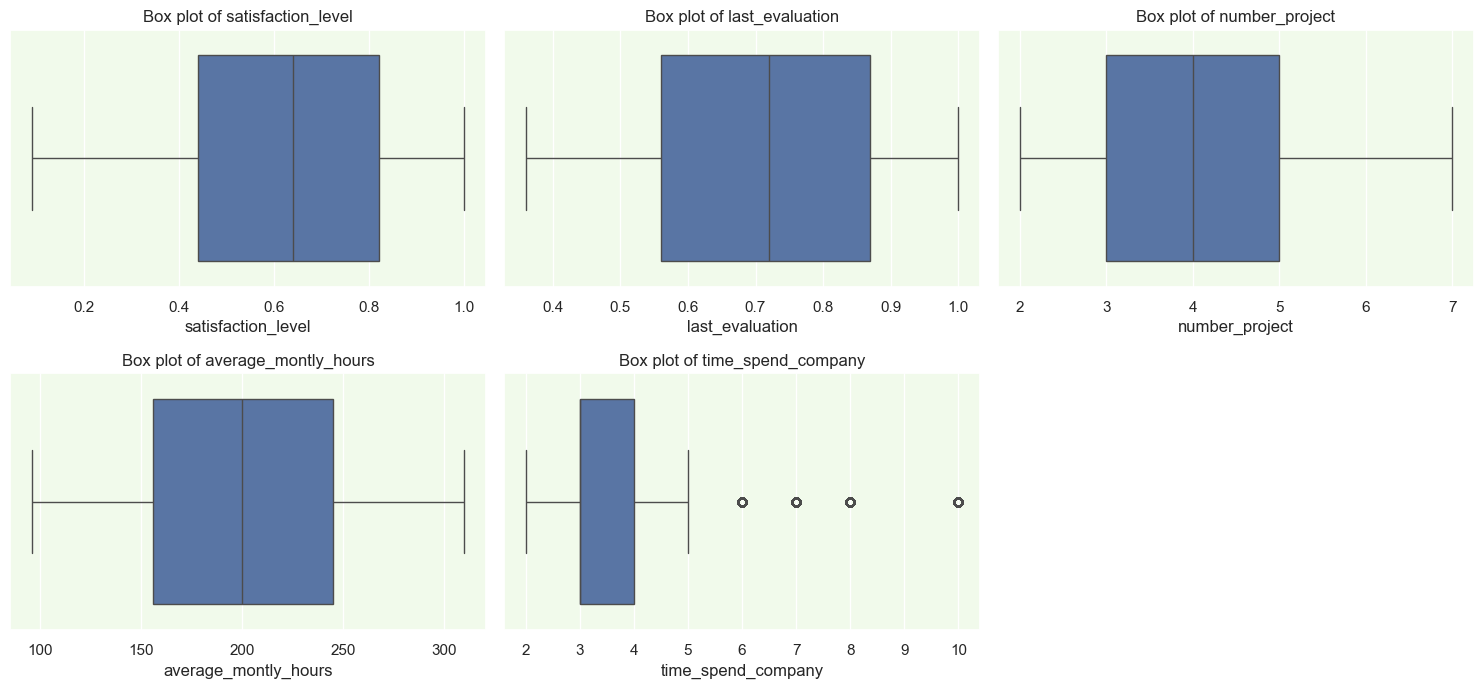

In [10]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(df[continuous_features]):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f'Box plot of {col}')
plt.tight_layout()
plt.show()

<h3 align="left"><font color=#009c05>Interpretation of Numerical Features</font></h3>

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">

I start with checking outliers and how the data is structured.

`time_spend_company` is interesting to see with outliers. It may help us predict turnover. But, this is more of telling us that it is not normal to see people with large tenure. This should be expected if the company is asking us to investigate on how to reduce turnover rate.

`number_projects` shows that its not normal to see more than 5 projects and less than 3.

`satisfaction_level` appears to have a rates below ~45% to be not normal.

Let's see the distributions

<a id="distro"></a>
## <b><span style='color:#8fc265'>Step 4.2 |</span><span style='color:#009c05'> Distributions</span></b> 

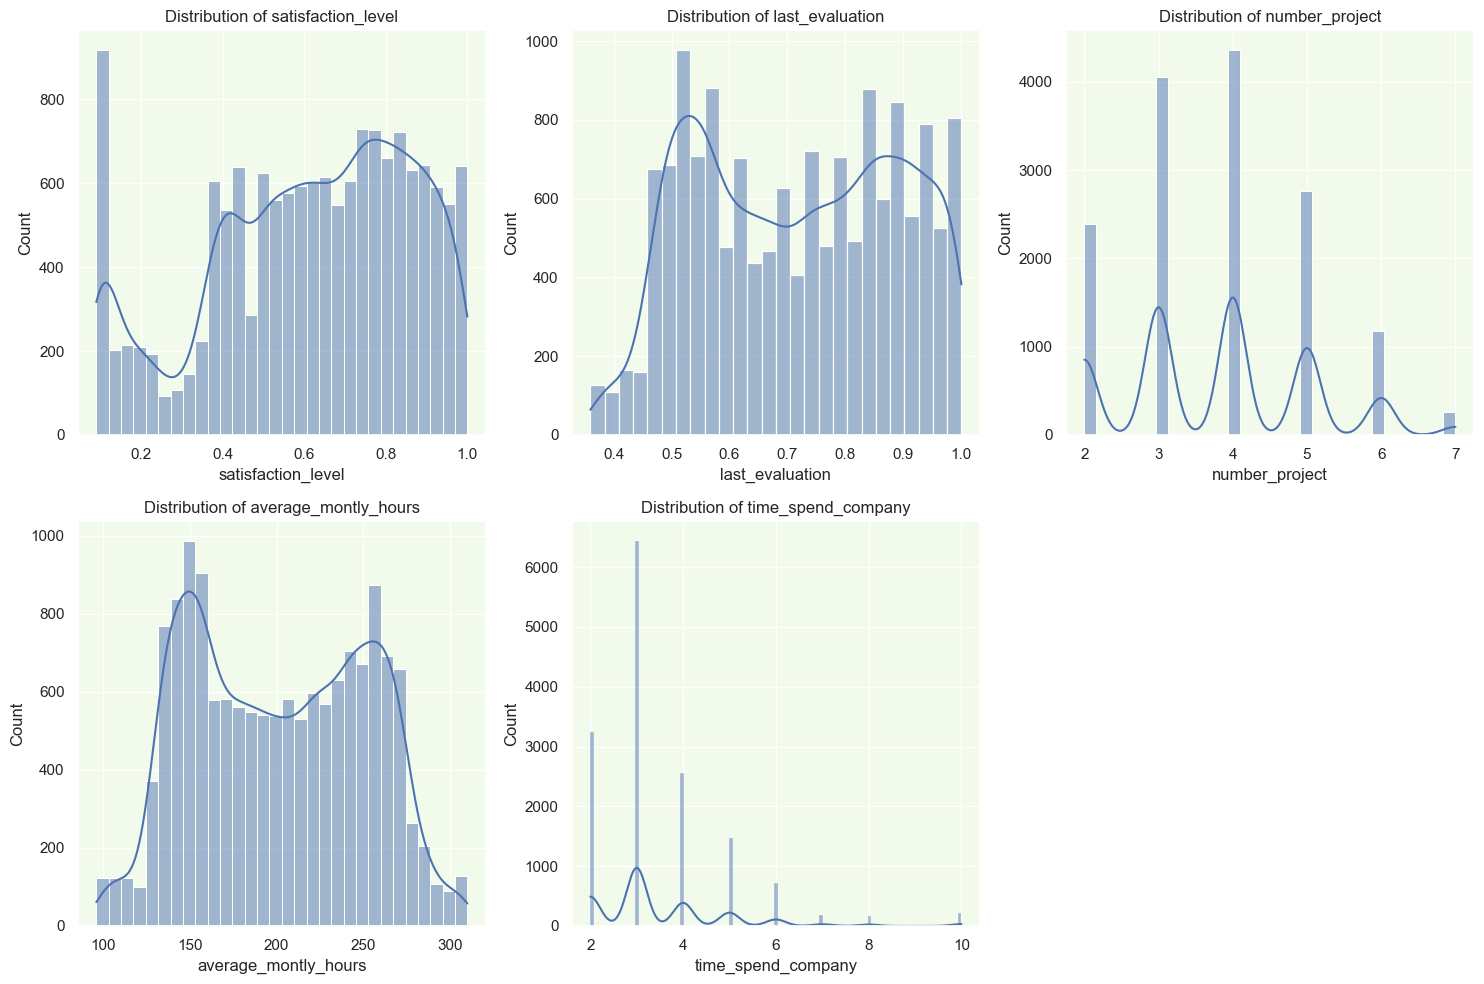

In [11]:
# Checking the distribution of continuous features
plt.figure(figsize=(15, 10))
for i, col in enumerate(continuous_features):
    plt.subplot(2, 3, i + 1)
    # we can control the amount of bins with the bins parameter
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

<h3 align="left"><font color=#009c05>Interpretation of Raw Distributions</font></h3>

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">

`number_project` and `time_spend_company` would be normal distributions with a right skew if they were continuous.

`satisfaction_level` is multimodal but you can see a significant count around the 10% mark. A majority of people are satisfied with their job but there is a lot of people who do not like their job.

`last_evaluation` and `montly_hours` are bimodal which means I am dealing with two distinct populations.

Let's see if this is distinguishable based on if employees left.

Let's apply some scaling and normalize the data to see how well I can find a good distribution.

<a id="scale_norm"></a>
## <b><span style='color:#8fc265'>Step 4.3 |</span><span style='color:#009c05'> Scaling and Normalization</span></b>  

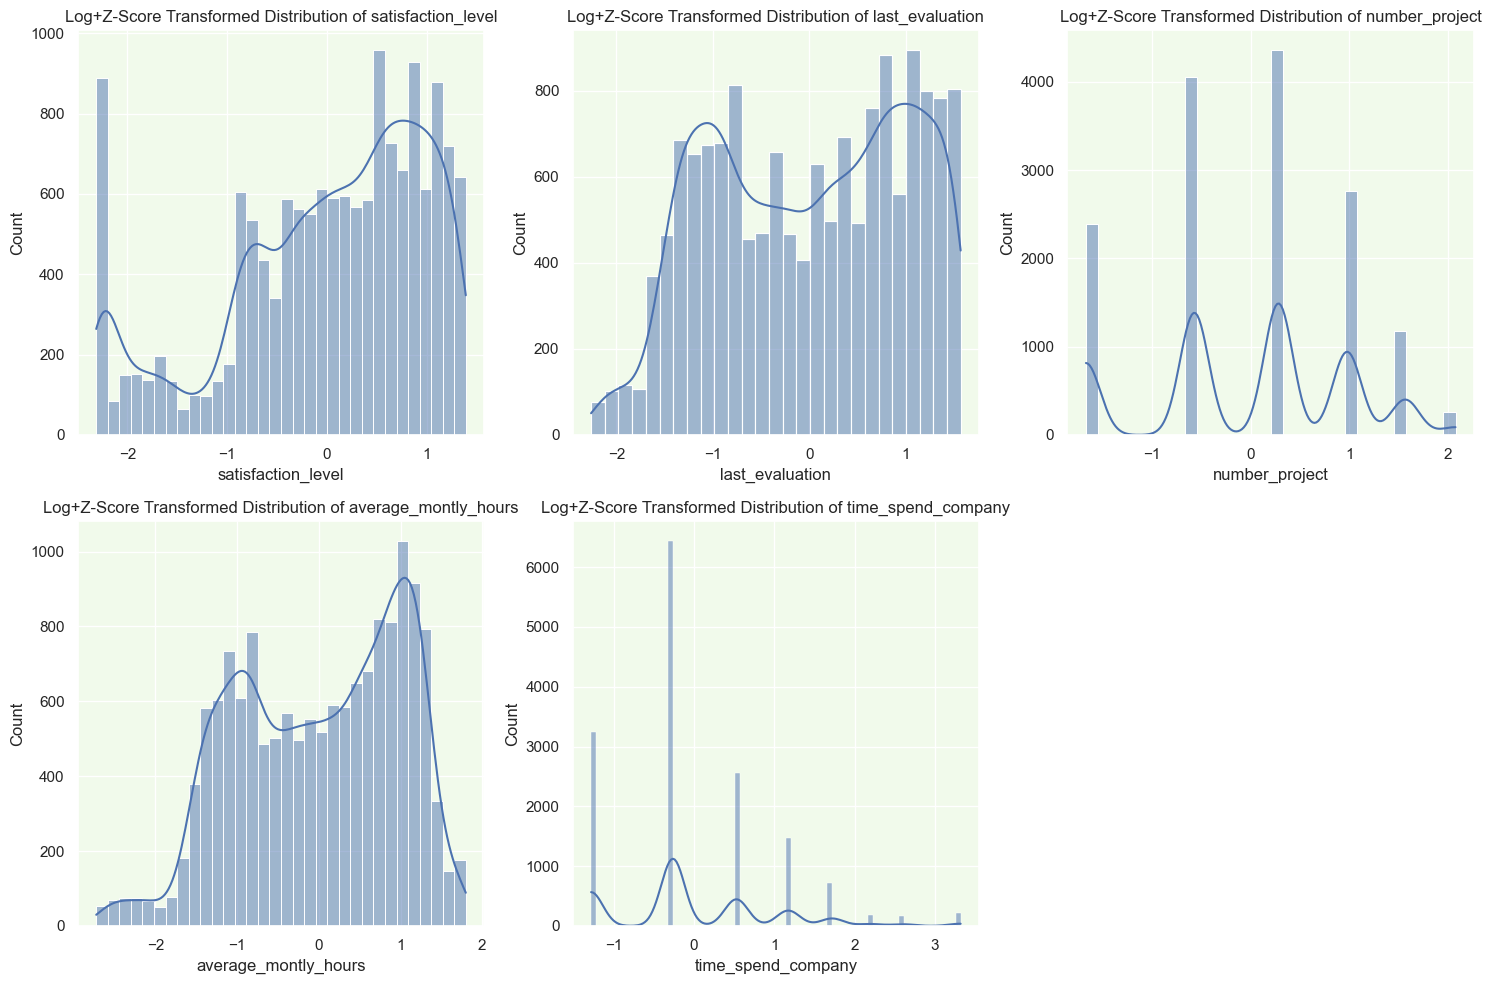

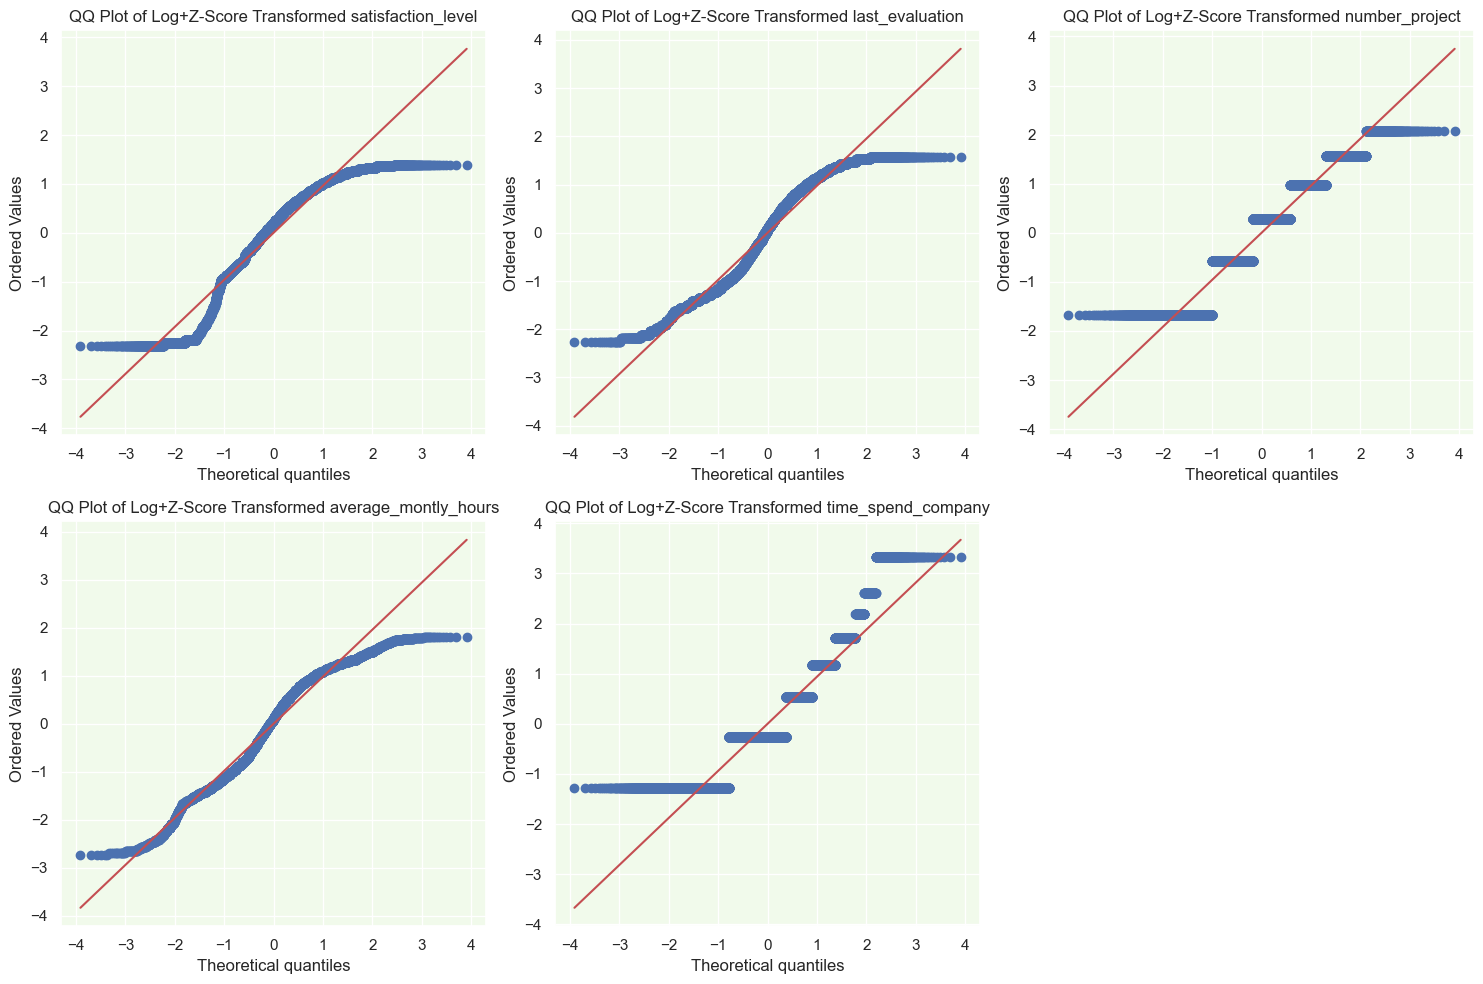

In [12]:
# Apply log transformation to the continuous features first
df_log_transformed = df.copy()
for col in continuous_features:
    df_log_transformed[col] = np.log1p(df_log_transformed[col])
    

# Now apply z-score normalization to the log-transformed data
df_log_zscore = df_log_transformed.copy()
for col in continuous_features:
    mean = df_log_zscore[col].mean()
    std = df_log_zscore[col].std()
    df_log_zscore[col] = (df_log_zscore[col] - mean) / std

# Plot the distributions after log + z-score transformation
plt.figure(figsize=(15, 10))
for i, col in enumerate(continuous_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df_log_zscore[col], kde=True)
    plt.title(f'Log+Z-Score Transformed Distribution of {col}')
plt.tight_layout()
plt.show()

# QQ plots for df_log_zscore data
plt.figure(figsize=(15, 10))
for i, col in enumerate(continuous_features):
    plt.subplot(2, 3, i + 1)
    stats.probplot(df_log_zscore[col], dist="norm", plot=plt)
    plt.title(f'QQ Plot of Log+Z-Score Transformed {col}')
plt.tight_layout()
plt.show()

<h2 align="left"><font color='#009c05'>Interpretation of Normalization Results</font></h2>

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">

I use histogram plots to see how well the data is normalized. QQ plots can be misleading if the data is multimodal but I believe is better to visualize a normal distribution this way as well.

However, it seems that all my attempts to normalize each feature individually have not yielded satisfactory results.

This is significant because normalization is important for many machine learning algorithms that assume or perform better when the data is normally distributed.

This will impact algorithms such as linear regression, logistic regression, and neural networks, which can be sensitive to the scale and distribution of the input features.

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">

Now I have a properly scaled dataset and is normalized to the best of my abilities.

I must keep in mind that normalization will not always be perfect but I can combine methods to increase our normalization process.

**Note**: It is possible to have too much transformation. So I have to be careful to not over handle this process and/or
lose the information to the point I cannot reverse the transformation.

Let's see if I can quickly grasp if there are any significant relationships between these features using the **pingouins** package `pairwise_corr()`.

<a id="corr_sig"></a>
## <b><span style='color:#8fc265'>Step 4.4 |</span><span style='color:#009c05'> Correlation & Significance</span></b>  

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">

I must assume that there is **no correlation** between the features of the data (*satisfaction level, number projects, etc.*).

This will be outlined as our **NULL Hypothesis**.

Let's determine if I can **Reject the NULL Hypothesis** with proof that there is a correlation

OR

I **Fail to Reject the NULL Hypothesis** and conclude that I just do not have substantial evidence to proceed further with the provided features.

In [13]:
# Adding a p-correction to the correlation matrix using pingouin
pg.pairwise_corr(df_log_zscore[continuous_features], padjust='fdr_bh')

,X,Y,method,alternative,n,r,CI95%,p-unc,p-corr,p-adjust,BF10,power
0,satisfaction_level,last_evaluation,pearson,two-sided,14999,0.085303,"[0.07, 0.1]",1.246449e-25,1.384944e-25,fdr_bh,6.17e+21,1.000000
1,satisfaction_level,number_project,pearson,two-sided,14999,-0.103366,"[-0.12, -0.09]",6.532582e-37,8.165727e-37,fdr_bh,9.709e+32,1.000000
2,satisfaction_level,average_montly_hours,pearson,two-sided,14999,-0.013593,"[-0.03, 0.0]",9.598506e-02,9.598506e-02,fdr_bh,0.041,0.384034
3,satisfaction_level,time_spend_company,pearson,two-sided,14999,-0.155278,"[-0.17, -0.14]",1.380782e-81,2.761564e-81,fdr_bh,3.027e+77,1.000000
4,last_evaluation,number_project,pearson,two-sided,14999,0.371998,"[0.36, 0.39]",0.000000e+00,0.000000e+00,fdr_bh,inf,1.000000
5,last_evaluation,average_montly_hours,pearson,two-sided,14999,0.344313,"[0.33, 0.36]",0.000000e+00,0.000000e+00,fdr_bh,inf,1.000000
6,last_evaluation,time_spend_company,pearson,two-sided,14999,0.134010,"[0.12, 0.15]",4.675912e-61,7.793187e-61,fdr_bh,1.041e+57,1.000000
7,number_project,average_montly_hours,pearson,two-sided,14999,0.410411,"[0.4, 0.42]",0.000000e+00,0.000000e+00,fdr_bh,inf,1.000000
8,number_project,time_spend_company,pearson,two-sided,14999,0.204975,"[0.19, 0.22]",5.258939e-142,1.314735e-141,fdr_bh,5.916e+137,1.000000
9,average_montly_hours,time_spend_company,pearson,two-sided,14999,0.124040,"[0.11, 0.14]",1.675784e-52,2.393978e-52,fdr_bh,3.145e+48,1.000000


<h3 align="left"><font color=#009c05>Interpretation of Pairwise Relationships</font></h3>

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">

The `pairwise_corr()` table gives me a detailed overview of any correlation between the features along with its significance.

For example, I can take the correlation between `satisfaction_level` and `last_evaluation` to be a significant relationship due to the low `p-corr`.

*This isn't the most significant but mentioned as an example since it is the first record on the table that indicates a significance.*

>(***corrected p-value***: is the p-value adjusted due to multiple test which can increase the false positive rate).

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">

However, I can also see that the **r** value (*correlation*) are typically weak in both positive & negative directions for the majority of
the features within the dataset.

Let's focus on the correlation and make it a bit easier to read using a **correlation matrix**.

Text(0.5, 1.0, 'Correlation Matrix of Continuous Features')

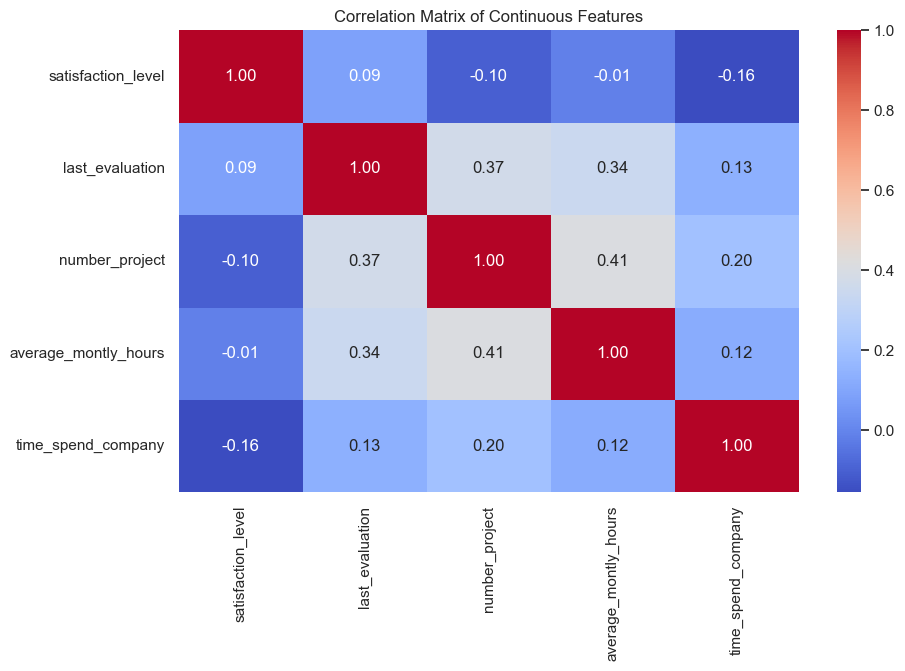

In [14]:
# Find the covariances between the continuous features
correlation_matrix = df_log_zscore[continuous_features].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Continuous Features')

<h3 align="left"><font color=#009c05>Interpretation of Correlation Matrix</font></h3>

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">

Nothing appears to be highly correlated which is to be expected due to the summary provided by the `pingouin` package. 

There is a moderate positive correlation between `average_montly_hours` and `number_projects` [0.42].

This is followed by a significant *corrected* p-value that is so close to zero, we cannot see it within the summary. 

This means that I can conclude I have a high degree of confidence that there is a positive correlation between `average_montly_hours` and `number_projects`

There is also a weak **positive** correlation between `last_evaluation` and `number_project` [0.37].

Although not as *highly* correlated as `average_montly_hours`, the *corrected* p-value indicates that this relationship is compelling.

Conversely, I can see that `satisfaction_level` has a **negative** correlation with `time_spend_company` indicating that the more one stays at the company, the less satisfied they become.


Now that I have this understanding, let's see the distribution between the employees that left vs those that stayed since I want to predict employee churn.

<a id="num_left"></a>
## <b><span style='color:#8fc265'>Step 4.5 |</span><span style='color:#009c05'> Numerical Features vs Employees that Left</span></b>  

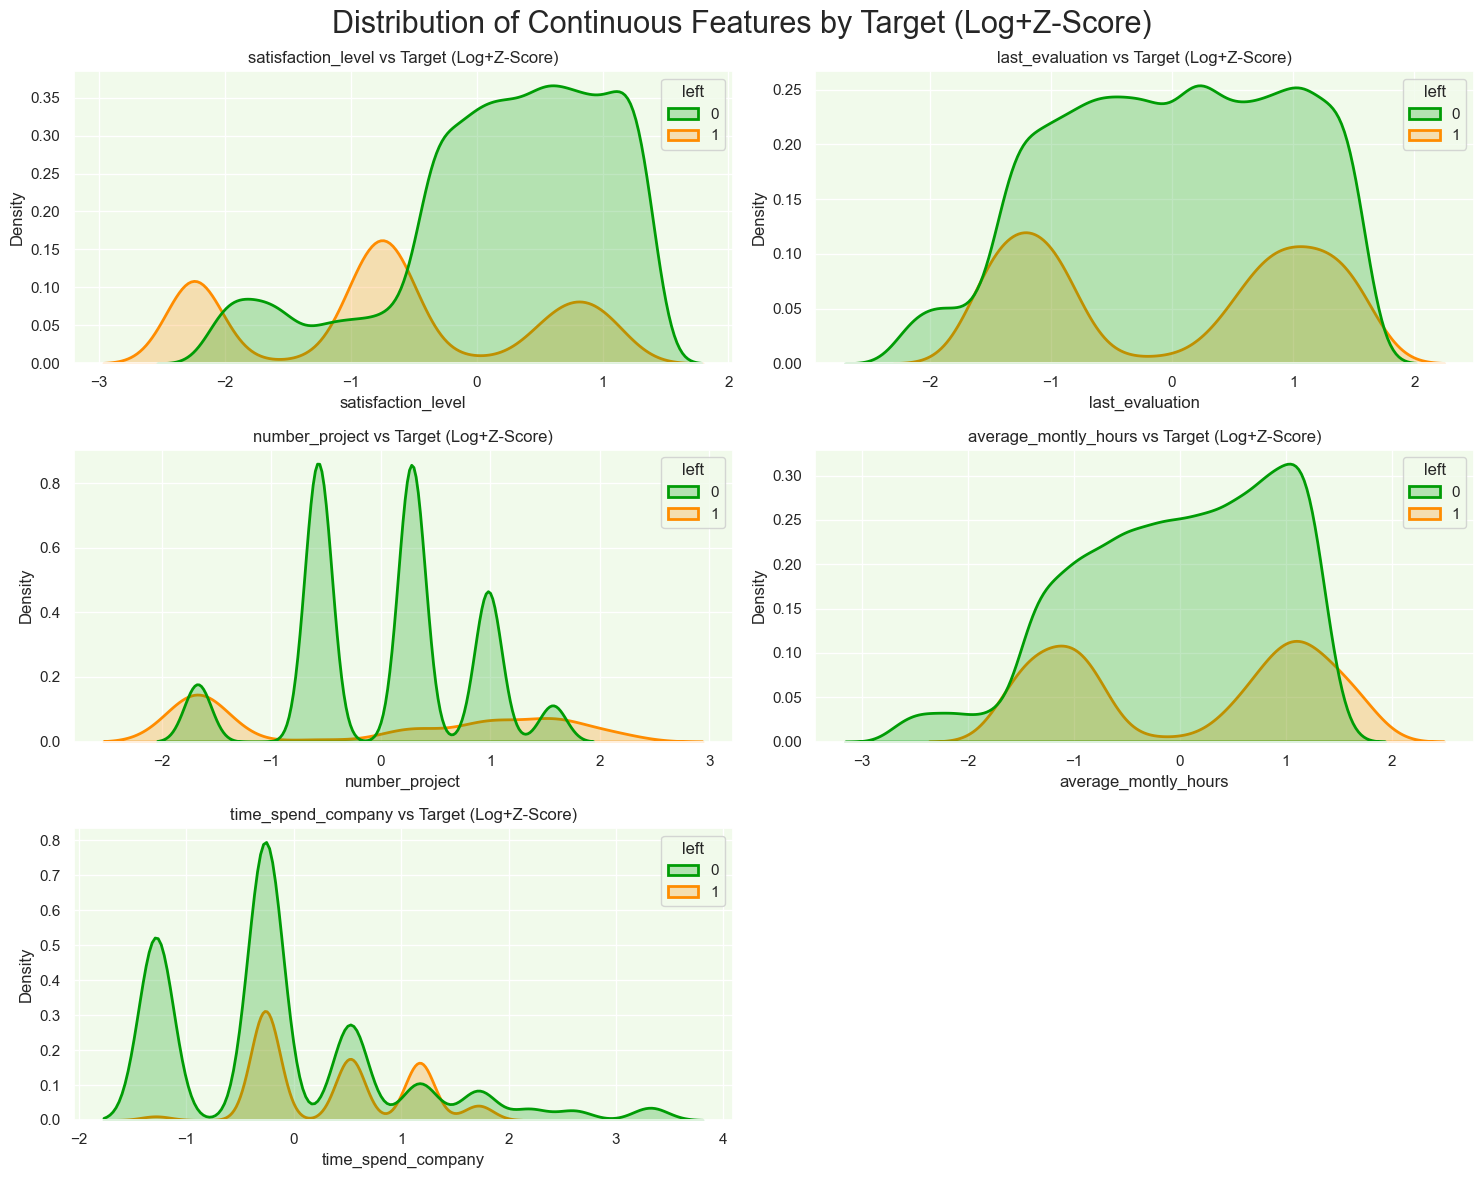

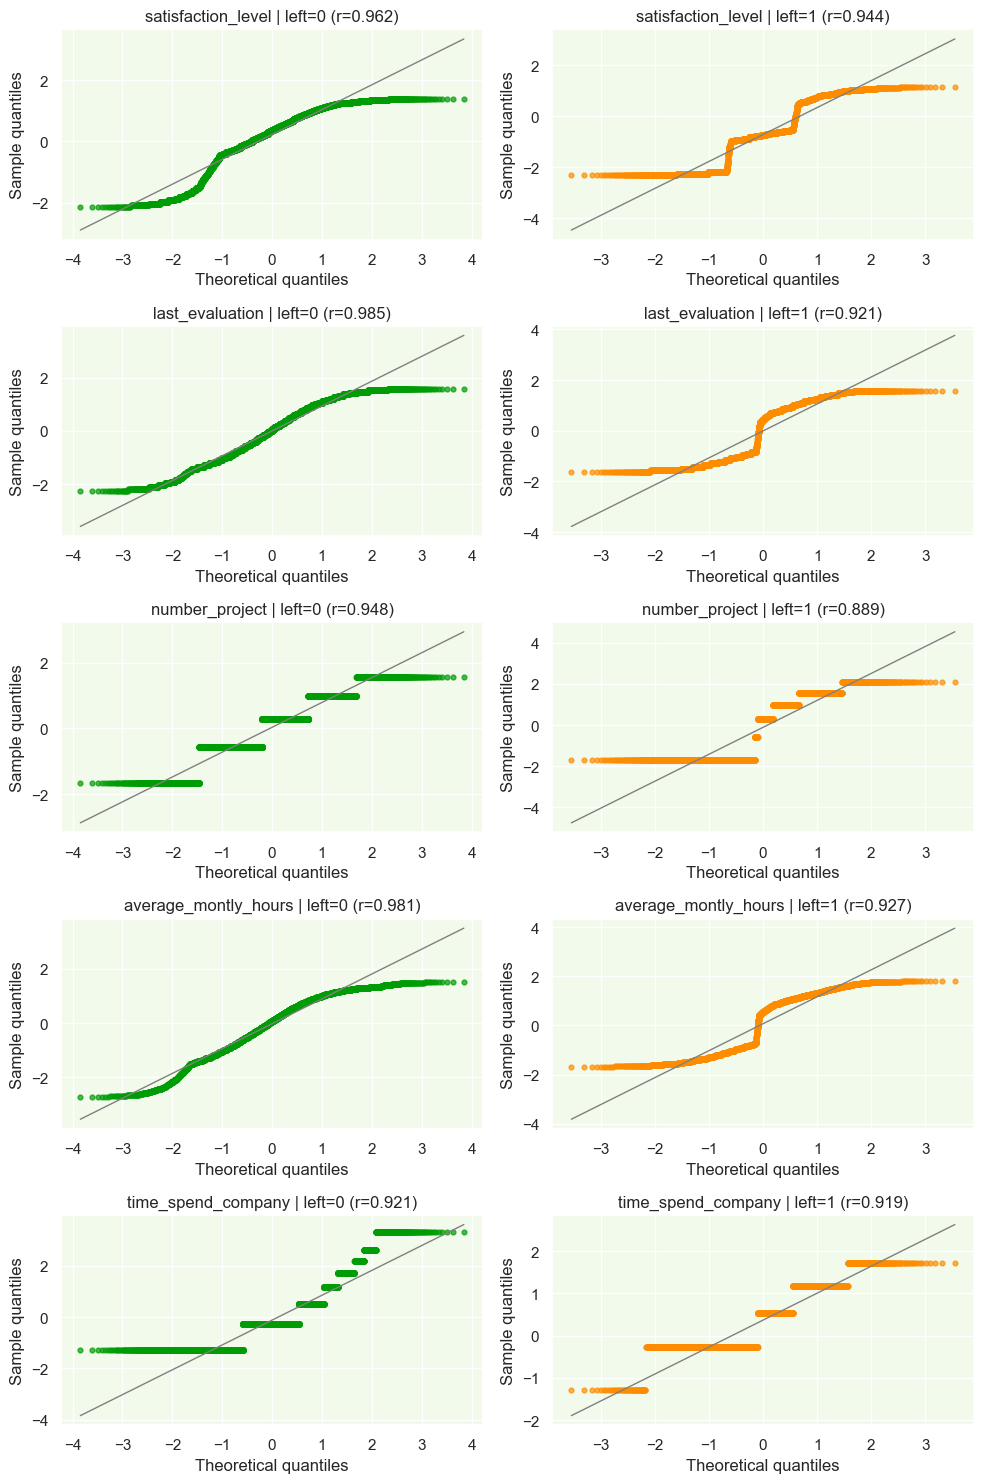

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

for ax, col in zip(axes.flatten(), continuous_features):
    sns.kdeplot(
        data=df_log_zscore,
        x=col,
        fill=True,
        linewidth=2,
        hue='left',
        ax=ax,
        palette={0: '#009c05', 1: 'darkorange'}
    )
    ax.set_title(f'{col} vs Target (Log+Z-Score)')

axes[2, 1].axis('off')
plt.suptitle('Distribution of Continuous Features by Target (Log+Z-Score)', fontsize=22)
plt.tight_layout()
plt.show()

# QQ plots for both left values in df_log_zscore data
labels = [0, 1]
fig, axes = plt.subplots(len(continuous_features), 2, figsize=(10, 3 * len(continuous_features)))

for r, col in enumerate(continuous_features):
    for c, lbl in enumerate(labels):
        subset = df_log_zscore.loc[df_log_zscore['left'] == lbl, col].dropna()
        (osm, osr), (slope, intercept, r_val) = stats.probplot(subset, dist="norm")
        ax = axes[r, c]
        ax.scatter(osm, osr, s=12, alpha=0.7, color='#009c05' if lbl == 0 else 'darkorange')
        # Reference line
        ax.plot(osm, slope * osm + intercept, color='gray', linewidth=1)
        ax.set_title(f'{col} | left={lbl} (r={r_val:.3f})')
        ax.set_xlabel('Theoretical quantiles')
        ax.set_ylabel('Sample quantiles')
        
plt.tight_layout()
plt.show()

<h3 align="left"><font color=#009c05>Review of Employees That Stayed and Left Distributions</font></h3>

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">

This is as best as I could do it. However, it does show some pretty remarkable trends for the employees that left.

For instance:

* A majority of the population of people who left had a `satisfaction_level` below the mean

* In contrast to the population that stayed
  * This means that the satisfaction level contains more dissatisfied employees who are likely to leave, which shouldn't be a surprise.

* Both `montly_hours` and `last_evaluation` shows similar trends to each other which may suggest a correlation to turnover between these three factors.
  * This may introduce more noise to our model or we may be able to remove one of these features since they seem highly correlated.

* Lastly, it seems that tenure is just a bit above the average for the turnover population as the `time_spend_company` suggests

Since we are dealing with categorical target variable, a linear regression model may not be the best fit for this type of problem.

So let's consider our options before we proceed to modeling.
1. We applied log transformation and z-score normalization to our continuous features.
2. We don't have a normal distribution for any of our continuous features.
3. Even after splitting the data based on employees that left vs those that stayed, we still do not have normal distributions for both cases.

This leaves us with using non-parametric models for classification. This will result to using logistic regression, decision trees, or random forests as opposed to linear regression. 

Let's preprocess the data and prepare it for modeling.

<a id="preprocessing"></a>
# <p style="background-color:#009c05; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 5 | Data Preprocessing</p>

⬆️ [Tabel of Contents](#contents_tabel)

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">

Data preprocessing is a crucial step in any machine learning project. It involves cleaning and transforming raw data into a format that can be understood by machine learning algorithms. For this project, the following preprocessing steps will be performed:

1. __Check Missing Values__
    
2. __Categorical Features Encoding__

3. __Split the Dataset__
    

<a id="missing"></a>
## <b><span style='color:#8fc265'>Step 5.1 |</span><span style='color:#009c05'> Check Missing Values</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">
    
First, check for any missing values in the dataset and handle them appropriately:

In [16]:
df_log_zscore.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  float64
 3   average_montly_hours   14999 non-null  float64
 4   time_spend_company     14999 non-null  float64
 5   Work_accident          14999 non-null  object 
 6   left                   14999 non-null  object 
 7   promotion_last_5years  14999 non-null  object 
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(5), object(5)
memory usage: 1.1+ MB


<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">
Our dataset has no missing values, eliminating the need for imputation or removal decisions that could introduce bias or reduce our dataset size.

Will also need to convert some of the object types back to int or float for modeling.

In [17]:
# Convert binary/target columns back to int for modeling
cols_to_int = ['Work_accident', 'promotion_last_5years', 'left']
for col in cols_to_int:
    if col in df_log_zscore.columns:
        df_log_zscore[col] = df_log_zscore[col].astype(int)

In [18]:
# Build reduced feature set and target
a = ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours',
     'time_spend_company', 'Work_accident', 'promotion_last_5years', 'left']
prep_data = df_log_zscore[a].copy()

# Separate features (X) and target variable (y)
X = prep_data.drop(['left', 'last_evaluation', 'average_montly_hours'], axis=1)

# For testing side by side
X_with = prep_data.drop(['left'], axis=1)

y = prep_data['left'].astype(int)

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">

After performing several tests, I noticed that `last_evaluation` and `average_montly_hours` does not help the model.

This was outlined in our distribution subplots. However, I did not suspect that removing both would help the model!

<a id="train_split"></a>
## <b><span style='color:#8fc265'>Step 5.2 |</span><span style='color:#009c05'> Train/Test Split</span></b>

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">

I used **Stratification** which ensures that the distribution of the target variable `left` is the same in both the train and test sets

I split the dataset into x and y where x is the features and y is the target variable. For example: `left` is the target variable and the rest are features.

In [20]:
# Train/score WITHOUT the two features (uses your existing split)
lm = LogisticRegression(max_iter=1000, random_state=0).fit(X_train, y_train)
acc = lm.score(X_test, y_test)

# Align X_with to the same split using indices
X_with_train = X_with.loc[X_train.index]
X_with_test  = X_with.loc[X_test.index]

# Train/score WITH the two features
lm_with = LogisticRegression(max_iter=1000, random_state=0).fit(X_with_train, y_train)
acc_with = lm_with.score(X_with_test, y_test)

# Adding ROC AUC for more context
auc = roc_auc_score(y_test, lm.predict_proba(X_test)[:, 1])
auc_with = roc_auc_score(y_test, lm_with.predict_proba(X_with_test)[:, 1])

pd.DataFrame(
    {'Accuracy': [acc, acc_with], 'ROC AUC': [auc, auc_with]},
    index=['Without last_evaluation + average_montly_hours',
           'With last_evaluation + average_montly_hours']
)

,Accuracy,ROC AUC
Without last_evaluation + average_montly_hours,0.807467,0.812888
With last_evaluation + average_montly_hours,0.789067,0.826839


<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">

I can confirm that the removal of the two features did positively impact the model performance slightly.

I went from a **78.9%** accuracy to **80.7%** accuracy by simply removing two features!

The ROC AUC did decrease slightly from **82.7%** to **81.3%** when removing the two features.

What the ROC AUC tells me is that the model is slightly less capable of distinguishing between the classes.

I will delve more into this when plotting the graph later on.

In [21]:
# Without the two features
preds = lm.predict(X_test)

# With the two features
preds_with = lm_with.predict(X_with_test)

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">

Passing the predicted results to a variable for further analysis.

I will use the `preds_with` during the XGBoost modeling later on for comparison.

<a id="classification"></a>
## <b><span style='color:#8fc265'>Step 5.3 |</span><span style='color:#009c05'> Classification Report</span></b>

In [22]:
# Converting labels for left: 0=Stayed, 1=Left
label_order = [0, 1]
target_names = ['Stayed (0)', 'Left (1)']

# Text report with custom class names
print(classification_report(
    y_test,
    preds,                 # from lm.predict(X_test)
    target_names=target_names,
    digits=3               # set decimal places
))

              precision    recall  f1-score   support

  Stayed (0)      0.847     0.912     0.878      2857
    Left (1)      0.627     0.471     0.538       893

    accuracy                          0.807      3750
   macro avg      0.737     0.692     0.708      3750
weighted avg      0.794     0.807     0.797      3750



<h3 align="left"><font color=#009c05>Review of Classification Report</font></h3>

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">

The results from the classification report shows that:

* the precision (proportion of positive predictions) is **85%** for people that stayed and **63%** for people that left
* Recall (proportion of actual vs correct predictions) is **91%** and **47%** respectively
* F1-Score (harmonic mean of precision and recall) is **88%** and **54%** respectively
* Overall our results show that the performance of our model is at **71%**, while the overall predictions shows **81%** which is influenced by the majority of the population (*employees that stayed*)

So, we will conclude that our model is at a **71%** performance rate (*Macro Average F1-Score*)

The reason is because Macro Average F1-Score gives equal weight to both classes, regardless of their frequency in the dataset.

* *This is important in imbalanced datasets like ours, where one class (employees that stayed) significantly outnumbers the other (employees that left).*

* *This ensures that the model's performance is evaluated fairly across both classes, rather than being dominated by the majority class.*

It's important to provide the **Precision**, **Recall**, and **F1-Score** for the class of employees that left the company because it gives us a better understanding of how well our model is performing in identifying employees who are at risk of leaving.


<a id="roc"></a>
## <b><span style='color:#8fc265'>Step 5.4 |</span><span style='color:#009c05'> ROC AUC Curve</span></b>

<Axes: title={'center': 'ROC curve'}, xlabel='False Positive Rate (FPR)', ylabel='True Positive Rate (TPR)'>

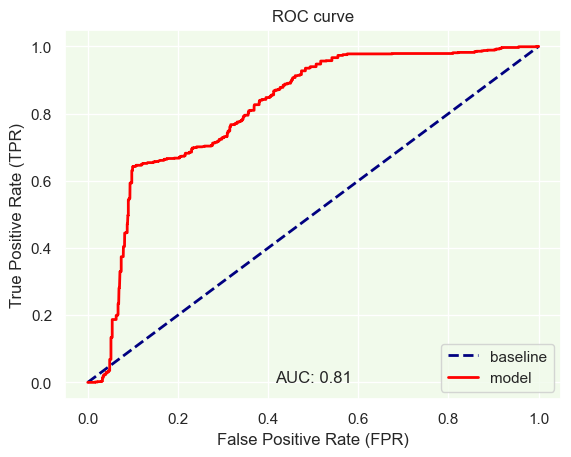

In [23]:
plot_roc(y_test, lm.predict_proba(X_test)[:,1])

<h3 align="left"><font color=#009c05>Interpretation of ROC AUC Curve</font></h3>

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">

The AUC (area under the curve) is **81%** which is good because it tells me that the model's performance regardless of the threshold (the cutoff point of the predicted probability value used to make binary classifications).

The threshold of the **cutoff point** is where:
- **Predicted probability ≥ threshold** → Classify as "1" (will leave)
- **Predicted probability < threshold** → Classify as "0" (will stay)

For example:
- **Threshold = 0.5**: Employee with 0.7 probability → "will leave" (0.7 ≥ 0.5)
- **Threshold = 0.5**: Employee with 0.3 probability → "will stay" (0.3 < 0.5)
- **Threshold = 0.7**: Employee with 0.6 probability → "will stay" (0.6 < 0.7)

The beauty of AUC is that it measures model discrimination ability across **ALL possible thresholds** from 0.0 to 1.0, giving me a single performance metric that's threshold-independent.

<a id="confusion_matrix"></a>
## <b><span style='color:#8fc265'>Step 5.5 |</span><span style='color:#009c05'> Confusion Matrix</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">
The confusion matrix provides specifics on how the model performs.

This is different from the **AUC** because the **AUC** provides you the *probability* of the performance whereas the confusion matrix tells you *where* the model is correctly identifying vs. incorrectly identifying at-risk employees.

This is further supported by:
* Accuracy: Correct predictions / all predictions
* Precision: Correct retention predictions / all retention predictions
* Recall: Correct retention predictions / all actual retention
* F1-Score: Harmonic mean of Precision and Recall (*P * R / P + R*)

Confusion Matrix — Without last_evaluation + average_montly_hours


,Pred Stayed (0),Pred Left (1)
Actual Stayed (0),2607,250
Actual Left (1),472,421



Confusion Matrix — With last_evaluation + average_montly_hours


,Pred Stayed (0),Pred Left (1)
Actual Stayed (0),2637,220
Actual Left (1),571,322


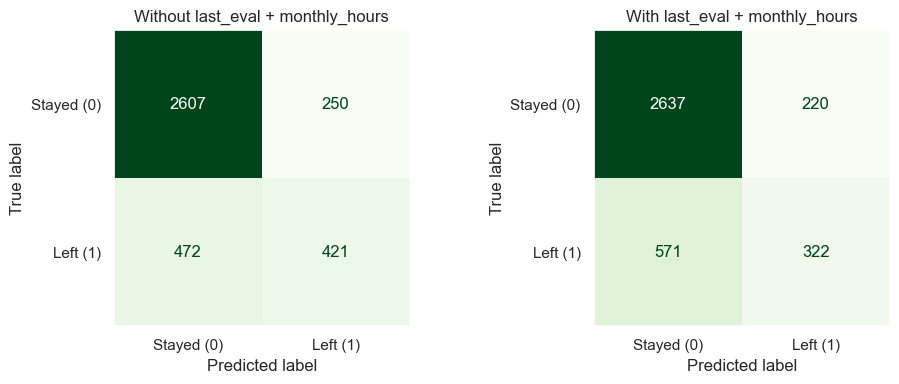

In [24]:
# Confusion matrices (tables)
cm_without = confusion_matrix(y_test, preds)      # without the two features
cm_with    = confusion_matrix(y_test, preds_with) # with the two features

print('Confusion Matrix — Without last_evaluation + average_montly_hours')
display(pd.DataFrame(cm_without, index=['Actual Stayed (0)','Actual Left (1)'], columns=['Pred Stayed (0)','Pred Left (1)']))

print('\nConfusion Matrix — With last_evaluation + average_montly_hours')
display(pd.DataFrame(cm_with, index=['Actual Stayed (0)','Actual Left (1)'], columns=['Pred Stayed (0)','Pred Left (1)']))

# Side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_without, display_labels=['Stayed (0)', 'Left (1)']).plot(ax=axes[0], cmap='Greens', colorbar=False)
axes[0].set_title('Without last_eval + monthly_hours'); axes[0].grid(False)

ConfusionMatrixDisplay(confusion_matrix=cm_with, display_labels=['Stayed (0)', 'Left (1)']).plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('With last_eval + monthly_hours'); axes[1].grid(False)

plt.tight_layout()
plt.show()

<h3 align="left"><font color=#009c05>Review of Confusion Matrix and Feature Importance</font></h3>

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">

The confusion matrix reaffirms my classification report by providing me actual values.

This helps to determine where the short gaps are with specifics and helps to determine how much is wrong in my model without the use of ratios since ratios could hide how significant the errors are.

Considering that my `Accuracy` increased by only **~1%** when removing the two features, it may not prove to be beneficial taking out the two columns.

Lastly, I have to consider the `Recall` for employees that left the company. Since this is what I'm ultimately trying to predict, I will conclude that it is better to remove the `last_evaluation` and `average_montly_hours` features since the `Recall` increased by **~11%** which is significant when trying to identify at-risk employees.

<a id="logistic_conclusion"></a>
## <b><span style='color:#8fc265'>Step 5.6 |</span><span style='color:#009c05'> Logistical Regression Conclusion</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">

Although I have conducted a complete analysis of our predictive model, I can further enhance its results since I'm not happy with the **80.7%** I saw in **Step 5.2 Train/Test Split**. It's okay and possibly acceptable in a business setting but, I'm interested in pushing the limits of our model.

For example, I can use **XGBoost** (*Extreme Gradient Boosting*) or **CatBoost** (*Categorical Boosting*) regressors like the original source to see if I can improve our model performance.



<a id="xgb"></a>
# <p style="background-color:#009c05; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 6 | Build XGBoost ~~Regressor~~ Classifier</p>

⬆️ [Tabel of Contents](#contents_tabel)

<a id="tune_xgb"></a>
## <b><span style='color:#8fc265'>Step 6.1 |</span><span style='color:#009c05'> Tune XGBoost Classifier</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">

The author uses XGBoost as a regressor but since we are dealing with a classification problem, I will use *XGBoost Classifier* instead. I will not pursue *CatBoost* in this analysis because I believe using XGBoost appropriately, it would yield similar results.

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">

The source created a function to tune the model with the best parameters by passing a dictionary of parameters to test. I will replicate this by using similar parameters to see if I can improve the model performance but with a classifier instead of a regressor.

In [25]:
# Function to tune XGBoost Classifier
def tune_xgb_classifier(X_train, y_train, scoring='', n_splits=5):
    """Grid-search XGBClassifier with stratified CV and a classification metric."""
    # Handle imbalance once, outside the search
    pos = int(y_train.sum())
    neg = int(len(y_train) - pos)
    spw = float(neg) / float(pos)

    base = xgb.XGBClassifier(
        objective='binary:logistic',
        # Adjust here for evaluating against PR Curve Setting ('aucpr')
        eval_metric='auc',
        # Set to use all available cores
        n_jobs=-1,
        random_state=0,
        # Apply scale_pos_weight to handle class imbalance
        scale_pos_weight=spw
    )

    # Hard coding parameters here to apply same range across multiple models
    param_grid = {
        'max_depth': [3, 4, 5], 
        'learning_rate': [0.02, 0.05, 0.1],
        'n_estimators': [200, 400, 800],
        'min_child_weight': [1, 3, 5],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0],
        'reg_lambda': [0.5, 1.0, 2.0],
        'gamma': [0, 1]
    }

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
    gs = GridSearchCV(
        estimator=base,
        param_grid=param_grid,
        scoring=scoring,          # 'roc_auc' or 'average_precision'
        cv=cv,
        n_jobs=-1,
        verbose=0,
        refit=True
    )
    gs.fit(X_train, y_train)
    # Optional: return cv results as DataFrame
    cv_results_df = pd.DataFrame(gs.cv_results_)
    return gs.best_estimator_, gs.best_params_, cv_results_df

<h3 align="left"><font color=#009c05>Explaination of XGB Classifier Function</font></h3>

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:120%; text-align:left; color: black">

The hardcoded hyperparameters for the XGBoost classifier function includes:
- `max_depth`:
  - Indicates the maximum depth of a tree
  - The higher the depth, the more complex the model which helps to reduce bias but may lead to overfitting
- `learning_rate`:
  - Step size shrinkage used to prevent overfitting
  - Overfitting can occur if the learning rate is too high
- `n_estimators`:
  - Number of trees to fit
  - More trees can improve performance but also increase computation time
- `min_child_weight`:
  - Minimum sum of instance weight needed in a child
  - Higher values prevent overfitting but may lead to underfitting
- `subsample`:
  - Fraction of samples to be used for fitting the individual base learners
  - Helps prevent overfitting by introducing randomness
- `colsample_bytree`:
  - Fraction of features to be used for fitting the individual base learners
  - Helps prevent overfitting by introducing randomness
- `reg_lambda`:
  - L2 regularization term on weights
  - Helps prevent overfitting by penalizing large weights
- `gamma`:
  - Minimum loss reduction required to make a further partition on a leaf node
  - Helps control overfitting by making the algorithm more conservative

I have to keep in mind that I also have reduced the features because of the risk of **multicollinearity** (i.e., `last_evaluation` and `average_montly_hours`).

My goal is to understand how much this model can improve while being cognizant of **overfitting**.

<a id="split_db"></a>
# <b><span style='color:#8fc265'>Step 6.2 |</span><span style='color:#009c05'> Split the Dataset</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:115%; text-align:left; color: black">

Now I will split the dataset again but using the **X_with** variable that contains `last_evaluation` and `average_montly_hours`

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:120%; text-align:left; color: black">

I'm going to use the regression algorithms as proposed by the source due to the same reasons provided below. The primary reason for me is the **Imbalanced Data** which is how my dataset is built.

1. __Probabilistic Interpretation__: Regression algorithms can predict a continuous output which can be interpreted as the probability of a certain event. In this case, the output can be interpreted as the probability that an employee will leave the company. This information can be more informative than just a binary output and can help in understanding how 'at risk' each employee is of leaving.

    
2. __Threshold Calibration__: By predicting probabilities, we can adjust the threshold for classifying an observation as 0 or 1. For example, we might classify all employees with a predicted probability of leaving greater than 0.5 as 'will leave'. However, we can adjust this threshold to be more conservative or more liberal depending on the cost of false positives and false negatives. For example, if it is more costly to incorrectly predict that an employee will stay when they actually leave, we might lower the threshold to 0.3 to identify more employees at risk of leaving.

    
3. __Imbalanced Data__: The target variable, `left`, is imbalanced with a larger proportion of employees who did not leave the company. This can sometimes lead to poor performance for classification algorithms because they have a bias towards the majority class. Regression algorithms do not have this bias and can sometimes perform better on imbalanced data.

Using regression algorithms will allow for a more nuanced understanding of the risk of each employee leaving, allow for threshold calibration, and might perform better on imbalanced data.


In [26]:
# Tune XGBoost Classifier on reduced feature set
best_clf, best_params, cvres = tune_xgb_classifier(X_train,
                                                   y_train,
                                                   # Change to 'average_precision' to test against PR curve
                                                   scoring='roc_auc',
                                                   # Splitting into 5 folds for increased reliability
                                                   n_splits=5
                                                   )

print('Best params:', best_params)

Best params: {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 400, 'reg_lambda': 0.5, 'subsample': 0.8}


<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:120%; text-align:left; color: black">

What is amazing is that the `tune_xgb_classifier()` function took only **~1 1/2 minutes** to run on my local machine!

Performance may vary but, it was able to find the most optimal parameters based on the range hardcoded into the function.

Let's see our results!

<a id="xgb_class_report"></a>
# <b><span style='color:#8fc265'>Step 6.3 |</span><span style='color:#009c05'> XGBoost Classification Report</span></b>

In [27]:
# Evaluate on test
# Get predicted probabilities
# [:, 1] gets the probabilities for the positive class
y_prob = best_clf.predict_proba(X_test)[:, 1]
print(f'Best XGB ROC AUC: {roc_auc_score(y_test, y_prob):.3f}')
y_pred = (y_prob >= 0.5).astype(int) # Need to set a threshold because predict_proba gives probabilities
print(classification_report(y_test, y_pred, target_names=['Stayed (0)', 'Left (1)'], digits=3))

Best XGB ROC AUC: 0.989
              precision    recall  f1-score   support

  Stayed (0)      0.982     0.974     0.978      2857
    Left (1)      0.920     0.942     0.931       893

    accuracy                          0.967      3750
   macro avg      0.951     0.958     0.954      3750
weighted avg      0.967     0.967     0.967      3750



<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:120%; text-align:left; color: black">

My model appears to be highly accurate and is able to identify employees that are at risk of leaving the company.

* the precision (proportion of positive predictions) is **98%** for people that stayed and **92%** for people that left
* Recall (proportion of actual vs correct predictions) is **97%** and **94%** respectively
* F1-Score (harmonic mean of precision and recall) is **98%** and **93%** respectively
* Overall our results show that the performance of our model is at **95%** (*macro avg*), while the overall predictions shows **~97%** (*weighted avg*) which is influenced by the majority of the population (*employees that stayed*)


**Note**: I haven't covered the ROC AUC even though I'm providing the results here. This is because my dataset is highly imbalanced. The ROC AUC may provide misleading results in imbalanced datasets because it considers the performance across all classification thresholds, which can be dominated by the majority class.

I will cover this in more details in the next section.

<a id="xgb_w_noise"></a>
# <b><span style='color:#8fc265'>Step 6.4 |</span><span style='color:#009c05'> Classification Report With Noise </span></b>

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:120%; text-align:left; color: black">

The ROC AUC of **0.989** is relatively high which leads me to be a bit skeptical. So, I will add a bit of noise to simulate the real world to see how well this model can perform. Of course, we can't take the results literally since we can't predict randomness. However, it will help us understand how well it can keep up with messy data.

In [28]:
np.random.seed(0) # for reproducibility

# Add Gaussian noise to continuous (non-binary) columns only
num_cols = [c for c in X_test.columns if np.issubdtype(X_test[c].dtype, np.number)]
cont_cols = [c for c in num_cols if X_test[c].nunique() > 2]  # exclude binary flags
noise_std = 0.1  # since data are z-scored, 0.1 = small perturbation

X_test_noisy = X_test.copy()
for col in cont_cols:
    X_test_noisy[col] = X_test_noisy[col] + np.random.normal(0, noise_std, size=X_test_noisy[col].shape)

# Evaluate on noisy test set
y_prob_noisy = best_clf.predict_proba(X_test_noisy)[:, 1]
y_pred_noisy = (y_prob_noisy >= 0.5).astype(int)
auc_noisy = roc_auc_score(y_test, y_prob_noisy)

# Summarize key metrics (focus on positive class = 1)
prec_o, rec_o, f1_o, _ = precision_recall_fscore_support(y_test, y_pred, labels=[1], average='binary')
prec_n, rec_n, f1_n, _ = precision_recall_fscore_support(y_test, y_pred_noisy, labels=[1], average='binary')

acc_o = accuracy_score(y_test, y_pred)
acc_n = accuracy_score(y_test, y_pred_noisy)

summary = pd.DataFrame({
    'Original': [auc, prec_o, rec_o, f1_o, acc_o],
    'Noisy':    [auc_noisy, prec_n, rec_n, f1_n, acc_n],
    'Delta (Noisy - Original)': [auc_noisy-auc, prec_n-prec_o, rec_n-rec_o, f1_n-f1_o, acc_n-acc_o]
}, index=['ROC AUC', 'Precision (1)', 'Recall (1)', 'F1 (1)', 'Accuracy'])

print('Classification report (original):')
print(classification_report(y_test, y_pred, target_names=['Stayed (0)', 'Left (1)'], digits=3))
print('Classification report (noisy):')
print(classification_report(y_test, y_pred_noisy, target_names=['Stayed (0)', 'Left (1)'], digits=3))

print('Summary (original vs. noisy):')
display(summary.round(3))

Classification report (original):
              precision    recall  f1-score   support

  Stayed (0)      0.982     0.974     0.978      2857
    Left (1)      0.920     0.942     0.931       893

    accuracy                          0.967      3750
   macro avg      0.951     0.958     0.954      3750
weighted avg      0.967     0.967     0.967      3750

Classification report (noisy):
              precision    recall  f1-score   support

  Stayed (0)      0.876     0.966     0.919      2857
    Left (1)      0.838     0.562     0.673       893

    accuracy                          0.870      3750
   macro avg      0.857     0.764     0.796      3750
weighted avg      0.867     0.870     0.860      3750

Summary (original vs. noisy):


,Original,Noisy,Delta (Noisy - Original)
ROC AUC,0.813,0.910,0.097
Precision (1),0.920,0.838,-0.082
Recall (1),0.942,0.562,-0.380
F1 (1),0.931,0.673,-0.258
Accuracy,0.967,0.870,-0.097


<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:120%; text-align:left; color: black">

I can see that the model still holds up relatively well even with the added noise. I can see that the performance has decreased to **~80%** (*macro avg F1-Score*). This is still great considering that I just added noise to it.

Let's examine this by visualizing it using both the **Receiver Operating Characteristic** (ROC) and **Precision-Recall** (PR) curves.

<a id="roc_noise_comp"></a>
# <b><span style='color:#8fc265'>Step 6.5 |</span><span style='color:#009c05'> ROC AUC With Noise Comparison </span></b>

<Figure size 600x400 with 0 Axes>

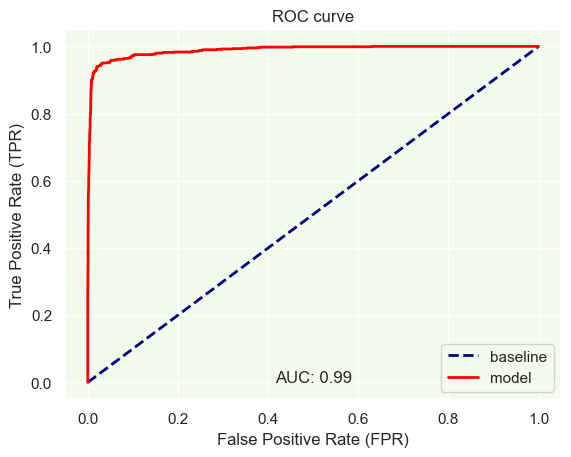

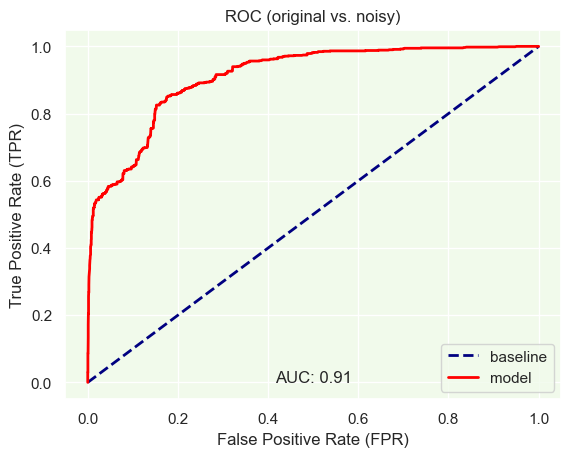

In [29]:
# Compare original vs noisy ROC curves
plt.figure(figsize=(6,4))
plot_roc(y_test, y_prob)
plot_roc(y_test, y_prob_noisy)
plt.title('ROC (original vs. noisy)')
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:120%; text-align:left; color: black">

The ROC curve is still performing well. However, I have to keep in mind that the ROC AUC can be misleading in imbalanced datasets.

This is why I alluded to the **Precision-Recall (PR) Curve** earlier.

<a id="pr_noise_comp"></a>
# <b><span style='color:#8fc265'>Step 6.6 |</span><span style='color:#009c05'> PR Curve With Noise Comparison </span></b>

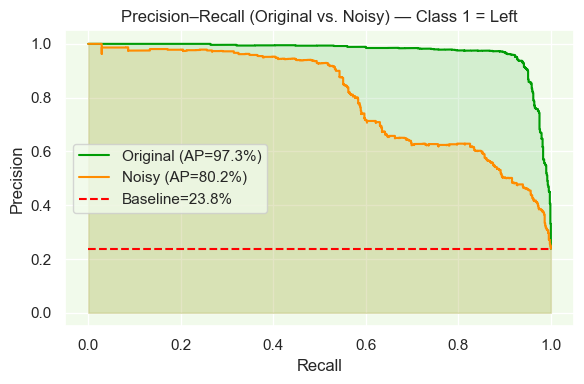

Average Precision — Original: 97.3% | Noisy: 80.2% | Delta: -17.1%


In [30]:
# Need to pass "_" because we don't need thresholds here
orig_precision, orig_recall, _ = precision_recall_curve(y_test, y_prob)
orig_avg_precision = average_precision_score(y_test, y_prob)

noisy_precision, noisy_recall, _ = precision_recall_curve(y_test, y_prob_noisy)
noisy_avg_precision = average_precision_score(y_test, y_prob_noisy)

positive_rate = (y_test == 1).mean()

plt.figure(figsize=(6,4))
plt.step(orig_recall, 
        orig_precision, 
        where='post', 
        color='#009c05', 
        label=f'Original (AP={orig_avg_precision:.1%})'
        )

plt.fill_between(orig_recall, 
                orig_precision, 
                step='post', 
                alpha=0.12, 
                color='#009c05'
                )

plt.step(noisy_recall, 
        noisy_precision, 
        where='post', 
        color='darkorange', 
        label=f'Noisy (AP={noisy_avg_precision:.1%})'
        )

plt.fill_between(noisy_recall, 
                noisy_precision, 
                step='post', 
                alpha=0.12, 
                color='darkorange'
                )

plt.hlines(positive_rate, 
           0, 
           1, 
           colors='red', 
           linestyles='dashed', 
           label=f'Baseline={positive_rate:.1%}'
           )

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall (Original vs. Noisy) — Class 1 = Left')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Average Precision — Original: {orig_avg_precision:.1%} | Noisy: {noisy_avg_precision:.1%} | Delta: {(noisy_avg_precision - orig_avg_precision):+.1%}')

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:120%; text-align:left; color: black">

Within the PR curve, I can see that the model is still performing relatively well even with the added noise. The delta of **-17.1%** indicates that the model's ability to identify true positives (employees who will leave) is still significantly better than random guessing.

The random guessing is represented by the baseline, which is calculated based on the proportion of positive instances in the dataset. In this case, the baseline is **23.8%**, meaning that if we were to randomly guess whether an employee would leave or not, we would be correct about **23.8%** of the time.

Seeing both the **ROC** and the **PR** curves together gives a more comprehensive understanding of the model's performance, especially in the context of imbalanced datasets.

<h3 align="left"><font color=#009c05>So What?</font></h3>

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:120%; text-align:left; color: black">

Well, I can take this model and deploy it into a production environment to help HR teams identify employees that are at risk of leaving the company.

Or if the decision is that we need to increase our sensitivity to the Recall metric (to catch more employees that are likely to leave), I can adjust the classification model's decision by adjusting the scoring parameter to use `average_precision` instead of `roc_auc`.

I could also set the evaluation metric `eval_metric` to be against the PR curve as well to help determine when to stop training based on the best results provided.

I'm not limited to this, I could pass `f1` or `logloss` as well depending on the business needs.

The fortunate thing is that I have a function pre-built to apply these changes quickly without having to re-build the model from scratch.

<a id="conclusion"></a>
# <p style="background-color:#009c05; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 7 | Conclusion</p>

⬆️ [Table of Contents](#contents_tabel)

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:120%; text-align:left; color: black">

<h3 align="left"><font color=#009c05>✅ Inference:</font></h3>

The provided XGBoost model demonstrates a good performance on both the training and testing data. The difference in metrics after applying noise to the data dropped as expected but still holds up relatively well.

Another indicator that reduced our overall performance is due to the imbalanced dataset which we applied parameters to help reduce this impact. The resulting ROC and PR curves also held up relatively well even with the added noise (ROC: **99%** to **91%**, PR: **97%** to **80%**). This tells me that my model has a strong ability to distinguish between employees that will leave vs those that will stay even with the added noise. I can also tell that the risk of overfitting is not significant since the model still performs well on the noisy data.

Moving forward I would **recommend to utilize the XGBoost** rather than the **logistic regression model** due to the significant increase in performance. However, I would also recommend to keep monitoring the model performance over time to ensure that it continues to perform well as new data is collected.

For confirmation as to why **logistic regression model** should **not** be used over the **XGBoost model** besides the increased performance, I can test it with adding noise as well. I suspect that there won't be a significant difference because it won't add the risk of overfitting like **XGBoost** however, it will still underperform compared to the **XGBoost** model.

<a id="xgb_hp"></a>
# <b><span style='color:#8fc265'>Step 7.1 |</span><span style='color:#009c05'> Validating XGBoost Over Logistical Regression </span></b>

,Original,Noisy,Delta (Noisy-Orig)
ROC AUC,0.813,0.811,-0.002
AP,0.499,0.483,-0.016
Precision(1),0.627,0.623,-0.004
Recall(1),0.471,0.450,-0.021
F1(1),0.538,0.523,-0.016
Accuracy,0.807,0.804,-0.003


Classification report (original):
              precision    recall  f1-score   support

  Stayed (0)      0.847     0.912     0.878      2857
    Left (1)      0.627     0.471     0.538       893

    accuracy                          0.807      3750
   macro avg      0.737     0.692     0.708      3750
weighted avg      0.794     0.807     0.797      3750

Classification report (noisy):
              precision    recall  f1-score   support

  Stayed (0)      0.842     0.915     0.877      2857
    Left (1)      0.623     0.450     0.523       893

    accuracy                          0.804      3750
   macro avg      0.733     0.683     0.700      3750
weighted avg      0.790     0.804     0.793      3750



<Figure size 600x400 with 0 Axes>

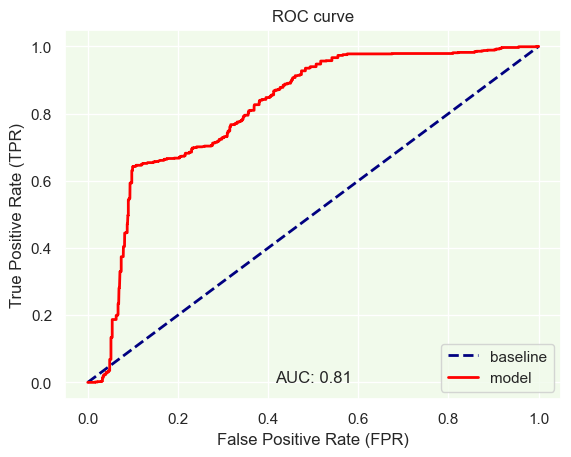

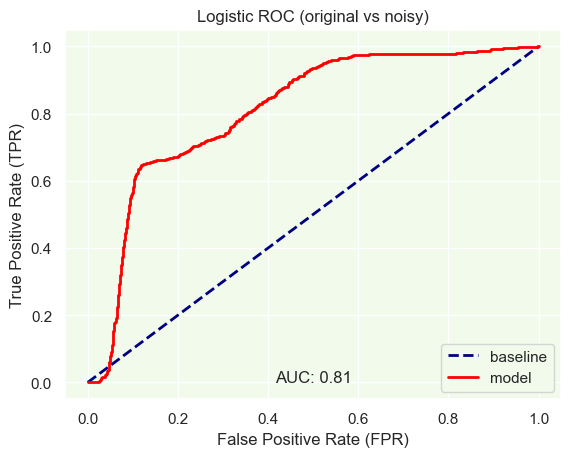

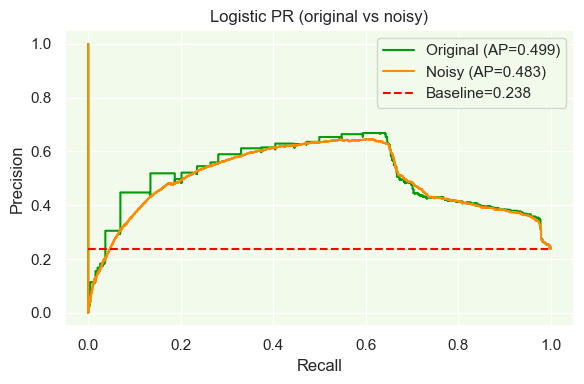

In [31]:
# Reestablish probability and prediction to remove xgboost enhancements
# Baseline probs & predictions
y_prob_lr = lm.predict_proba(X_test)[:, 1]
y_pred_lr = (y_prob_lr >= 0.5).astype(int)

# Add Gaussian noise to non-binary numeric columns
np.random.seed(0)
num_cols_lr = [c for c in X_test.columns 
               if np.issubdtype(X_test[c].dtype,
                                np.number)
               ]
cont_cols_lr = [c for c in num_cols_lr 
                if X_test[c].nunique() > 2 # exclude binary flags
                ]
noise_std = 0.1  # small, since features are z/log scaled

X_test_noisy_lr = X_test.copy()
for col in cont_cols_lr:
    X_test_noisy_lr[col] = X_test_noisy_lr[col] + np.random.normal(0,
                                                                   noise_std, 
                                                                   size=X_test_noisy_lr[col].shape
                                                                   )

# Noisy probs & predictions
y_prob_lr_noisy = lm.predict_proba(X_test_noisy_lr)[:, 1]
y_pred_lr_noisy = (y_prob_lr_noisy >= 0.5).astype(int)

# Metrics
roc_o = roc_auc_score(y_test, y_prob_lr)
roc_n = roc_auc_score(y_test, y_prob_lr_noisy)
ap_o = average_precision_score(y_test, y_prob_lr)
ap_n = average_precision_score(y_test, y_prob_lr_noisy)

prec_o, rec_o, f1_o, _ = precision_recall_fscore_support(y_test, 
                                                        y_pred_lr,
                                                        labels=[1],
                                                        average='binary'
                                                        )

prec_n, rec_n, f1_n, _ = precision_recall_fscore_support(y_test,
                                                        y_pred_lr_noisy,
                                                        labels=[1],
                                                        average='binary'
                                                        )

acc_o = accuracy_score(y_test, y_pred_lr)
acc_n = accuracy_score(y_test, y_pred_lr_noisy)

summary_lr = pd.DataFrame({
    'Original': [roc_o, ap_o, prec_o, rec_o, f1_o, acc_o],
    'Noisy':    [roc_n, ap_n, prec_n, rec_n, f1_n, acc_n],
    'Delta (Noisy-Orig)': [roc_n-roc_o, ap_n-ap_o, prec_n-prec_o, rec_n-rec_o, f1_n-f1_o, acc_n-acc_o]
}, index=['ROC AUC','AP','Precision(1)','Recall(1)','F1(1)','Accuracy']).round(3)

display(summary_lr)

print("Classification report (original):")
print(classification_report(y_test, y_pred_lr, target_names=['Stayed (0)','Left (1)'], digits=3))
print("Classification report (noisy):")
print(classification_report(y_test, y_pred_lr_noisy, target_names=['Stayed (0)','Left (1)'], digits=3))

# ROC overlay
plt.figure(figsize=(6,4))
plot_roc(y_test, y_prob_lr)
plot_roc(y_test, y_prob_lr_noisy)
plt.title('Logistic ROC (original vs noisy)')
plt.show()

# PR overlay
prec_o_curve, rec_o_curve, _ = precision_recall_curve(y_test, y_prob_lr)
prec_n_curve, rec_n_curve, _ = precision_recall_curve(y_test, y_prob_lr_noisy)
base_rate = (y_test == 1).mean()

plt.figure(figsize=(6,4))
plt.step(rec_o_curve, 
        prec_o_curve, 
        where='post', 
        color='#009c05', 
        label=f'Original (AP={ap_o:.3f})'
        )

plt.step(rec_n_curve, 
        prec_n_curve, 
        where='post', 
        color='darkorange', 
        label=f'Noisy (AP={ap_n:.3f})'
        )

plt.hlines(base_rate, 
           0, 
           1, 
           colors='red', 
           linestyles='dashed', 
           label=f'Baseline={base_rate:.3f}'
           )

plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Logistic PR (original vs noisy)')
plt.legend()
plt.tight_layout()
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #f0ffe3; font-size:120%; text-align:left; color: black">

As anticipated, the logistic regression model's performance also decreased with the addition of noise, but not as drastically as the XGBoost model. The **macro F1-Score** dropped from **71%** to **70%**, indicating that while the logistic regression model is less sensitive to noise, it still does not match the performance of the XGBoost model.

But it does mean that the performance of the logistical model will perform just as you expect it would with the addition of noise due to its simpler nature compared to more complex models like XGBoost. 


<h2 align="left"><font color='#009c05'>Best Regards!</font></h2>